# MNIST Handwritten Digit Classification (PyTorch CNN)

## Assignment Questions (Follow in Order)

- **Q1 (15 pts):** Build the MNIST data pipeline (transforms, train/val split, DataLoaders).
- **Q2 (20 pts):** Implement a CNN classifier with the specified architecture.
- **Q3 (40 pts):** Implement training and validation functions, run training loop with checkpointing, and plot curves.
  - 3.1 (15 pts): Training function
  - 3.2 (8 pts): Validation function
  - 3.3 (11 pts): Training loop with best checkpoint saving
  - 3.4 (6 pts): Plot training and validation curves
- **Q4 (5 pts):** Load the best checkpoint and evaluate on the test set.

**Total: 80 points**

---

## Starter Notebook (Student Version)

Fill in the sections marked with:

```python
# ========== YOUR CODE STARTS HERE ==========
# ========== YOUR CODE ENDS HERE ============
```

Do **not** change the rubric section above.

In [3]:
# If you are running in a fresh environment, uncomment to install dependencies:
#!pip -q install torch torchvision matplotlib tqdm scikit-learn

import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Dataset, Subset

import cv2
import pathlib
from PIL import Image
import pandas as pd

print("torch:", torch.__version__)
device = "cpu"  # For fixed, reproducible results. (You may switch to "cuda" after you finish debugging.)
print("device:", device)

def set_seed(seed: int = 42):
    """Make results as reproducible as possible across runs."""
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)
    # If you later switch to CUDA and want maximal determinism:
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)

/Users/asvay/Desktop/CSE144/cse_144_final
['submission.csv', 'README.md', 'CSE-144_HW2-1.ipynb', '.gitignore', '.git']
1.26.4
2.2.2
4.9.0
torch: 2.2.2
device: cpu


## 1. Dataset and DataLoader (15 pts)

In [ ]:
# for resizing purposes:
train_path = pathlib.Path("./train") # pathlib to train folder
for child in train_path.iterdir(): # iterate thru train
    for jpg in child.glob("*.jpg"): # iterate thru train's subfolders
        image = cv2.imread(jpg) # read image using cv2 (could use pillow i think)
        corrected = cv2.resize(image, (224, 224)) # resize 224 x 224

        # create new dir to work with
        # im prepending a 0 to solve the future class mapping problem I think this plays but we'll see
        if int(child.name) >= 0 and int(child.name) <= 9: 
            pathlib.Path(f'preprocessed/{0}{child.name}').mkdir(parents=True, exist_ok=True)
            cv2.imwrite(f'preprocessed/{0}{child.name}/{jpg.name}', corrected)
        else:
            pathlib.Path(f'preprocessed/{child.name}').mkdir(parents=True, exist_ok=True)
            cv2.imwrite(f'preprocessed/{child.name}/{jpg.name}', corrected)

# resizing for test, dont worry about prepending etc shouldnt matter, same deal but no subfolder iteration
test_path = pathlib.Path("./test")
for child in test_path.iterdir():
    image = cv2.imread(child)
    corrected = cv2.resize(image, (224, 224))
    pathlib.Path(f'preprocessed_test/').mkdir(parents=True, exist_ok=True)
    cv2.imwrite(f'preprocessed_test/{child.name}', corrected)

In [41]:
num_workers = 0  # For fully reproducible ordering across platforms
batch_size = 32 # can change later

train_path = pathlib.Path("./preprocessed") # new path for ImageFolder
test_path = pathlib.Path("./preprocessed_test") # new path for custom dataset

train_tf = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.485, 0.456, 0.406), (0.229,0.224, 0.225))])

train_tf_aug = transforms.Compose(
    [transforms.RandomHorizontalFlip(p=0.5), 
     transforms.ColorJitter(0.25, 0.25, 0.25, 0.1),
     transforms.RandomRotation(15),
     transforms.RandomResizedCrop(224),
     transforms.ToTensor(),
     transforms.Normalize((0.485, 0.456, 0.406), (0.229,0.224, 0.225))
     ])

test_tf = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.485, 0.456, 0.406), (0.229,0.224, 0.225))])
# after tensor transform, normalize w imagenet mean and std ^ (transfer learning!)

# custom test dataset because ImageFolder expects subfolders for mapping
class TestDataset(Dataset):
    def __init__(self, test_dir, transform=test_tf):
        self.test_dir = test_dir # test_dir should be /preprocessed_test
        self.transform = transform # transform default set, also pass in test_tf
        self.test_img_path = [] # img_path is a list of all of the image paths (used in getitem)
        
        for child in test_dir.iterdir():
            self.test_img_path.append(child)
        
        self.test_img_path = sorted(self.test_img_path, key=lambda p: int(p.stem))
        # sorted by int to prevent 10 before 2 type sorting ^

    def __len__(self):
        return len(self.test_img_path) # number of items in test
    
    def __getitem__(self, index):
        test_path = self.test_img_path[index]
        test_id = test_path.stem # return value for id, stem for clipped jpg

        image = Image.open(test_path)
        image = self.transform(image) # apply test_tf

        return image, test_id

full_train_aug = datasets.ImageFolder(train_path, transform=train_tf_aug)
full_train = datasets.ImageFolder(train_path, transform=train_tf)
test_set = TestDataset(test_path, transform=test_tf)
# load both datasets ^

indices = torch.randperm(len(full_train)).tolist()
train_indices = indices[:865]
val_indices = indices[865:]
train_set = Subset(full_train_aug, train_indices)
val_set = Subset(full_train, val_indices)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print("train/val/test:", len(train_set), len(val_set), len(test_set))
print(full_train.class_to_idx) # sanity check for 0 padded mapping



train/val/test: 865 214 1036
{'00': 0, '01': 1, '02': 2, '03': 3, '04': 4, '05': 5, '06': 6, '07': 7, '08': 8, '09': 9, '10': 10, '11': 11, '12': 12, '13': 13, '14': 14, '15': 15, '16': 16, '17': 17, '18': 18, '19': 19, '20': 20, '21': 21, '22': 22, '23': 23, '24': 24, '25': 25, '26': 26, '27': 27, '28': 28, '29': 29, '30': 30, '31': 31, '32': 32, '33': 33, '34': 34, '35': 35, '36': 36, '37': 37, '38': 38, '39': 39, '40': 40, '41': 41, '42': 42, '43': 43, '44': 44, '45': 45, '46': 46, '47': 47, '48': 48, '49': 49, '50': 50, '51': 51, '52': 52, '53': 53, '54': 54, '55': 55, '56': 56, '57': 57, '58': 58, '59': 59, '60': 60, '61': 61, '62': 62, '63': 63, '64': 64, '65': 65, '66': 66, '67': 67, '68': 68, '69': 69, '70': 70, '71': 71, '72': 72, '73': 73, '74': 74, '75': 75, '76': 76, '77': 77, '78': 78, '79': 79, '80': 80, '81': 81, '82': 82, '83': 83, '84': 84, '85': 85, '86': 86, '87': 87, '88': 88, '89': 89, '90': 90, '91': 91, '92': 92, '93': 93, '94': 94, '95': 95, '96': 96, '97': 97, 

## 3. Training Loop (40 pts)

### 3.1 Training Function (15 pts)

In [42]:
model_temp = models.resnet18(weights='IMAGENET1K_V1') # starting model taken from transfer learning tutorial
model_temp.fc = nn.Linear(model_temp.fc.in_features, 100) # resize out to 100
model_temp = model_temp.to(device)

for param in model_temp.parameters():
    param.requires_grad = False # freeze all params

for param in model_temp.fc.parameters():
    param.requires_grad = True # unfreeze last layer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_temp.parameters(), lr=1e-3)

def train_one_epoch(model, loader):
    """Train for one epoch and return (avg_loss, accuracy)."""
    total_loss = 0.0
    correct = 0
    total = 0

    model.train()
    

    for i, t in loader:

        i = i.to(device)
        t = t.to(device)

        optimizer.zero_grad()

        outputs = model(i)
        loss = criterion(outputs, t)
        loss.backward()

        optimizer.step()

        total_loss = total_loss + loss.item() * i.size(0)
        temp, predicted = torch.max(outputs, 1)

        for j in range(len(predicted)):
            if predicted[j].item() == t[j].item():
                matches = 1
            else:
                matches = 0
            correct = correct + matches

        total = total + t.size(0)
    
    return total_loss / len(loader.dataset), correct / total


### 3.2 Validation Function (8 pts)

In [43]:
# Q3.2: Validation function
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""

    total_loss = 0.0
    correct = 0
    total = 0

    model.eval()
    
    for i, t in loader:
        i = i.to(device)
        t = t.to(device)

        outputs = model(i)
        loss = criterion(outputs, t)

        total_loss = total_loss + loss.item() * i.size(0)
        temp, predicted = torch.max(outputs, 1)

        for j in range(len(predicted)):
            if predicted[j].item() == t[j].item():
                matches = 1
            else:
                matches = 0
            correct = correct + matches

        total = total + t.size(0)
    
    return total_loss / len(loader.dataset), correct / total


### 3.3 Training Loop (11 pts)

In [ ]:
# Q3.3: Training loop with checkpointing
epochs = 20
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./checkpoints/data_aug.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_temp, train_loader)
    val_loss, val_acc = evaluate(model_temp, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print()
    print("==============================================================")
    print("Epoch ", epoch + 1)
    print("Train Loss: ", train_loss )
    print("Train Acc: ", train_acc )
    print("Val Loss: ", val_loss )
    print("Val Acc: ", val_acc )
    print("==============================================================")
    print()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save({"model_state_dict": model_temp.state_dict(),"epoch": best_epoch}, ckpt_path)


print("Best val acc:", best_val_acc, "at epoch", best_epoch)
print("Saved to:", ckpt_path)


Epoch  1
Train Loss:  4.637851716741661
Train Acc:  0.05433526011560694
Val Loss:  4.229884934202533
Val Acc:  0.07009345794392523


Epoch  2
Train Loss:  3.6289701456279424
Train Acc:  0.1606936416184971
Val Loss:  3.633662348595735
Val Acc:  0.1542056074766355


Epoch  3
Train Loss:  3.1338023136116866
Train Acc:  0.22427745664739884
Val Loss:  3.3327118615123714
Val Acc:  0.16822429906542055


Epoch  4
Train Loss:  2.8248225096333233
Train Acc:  0.3213872832369942
Val Loss:  3.14054388197783
Val Acc:  0.22897196261682243



### 3.4 Plot Training Curves (6 pts)

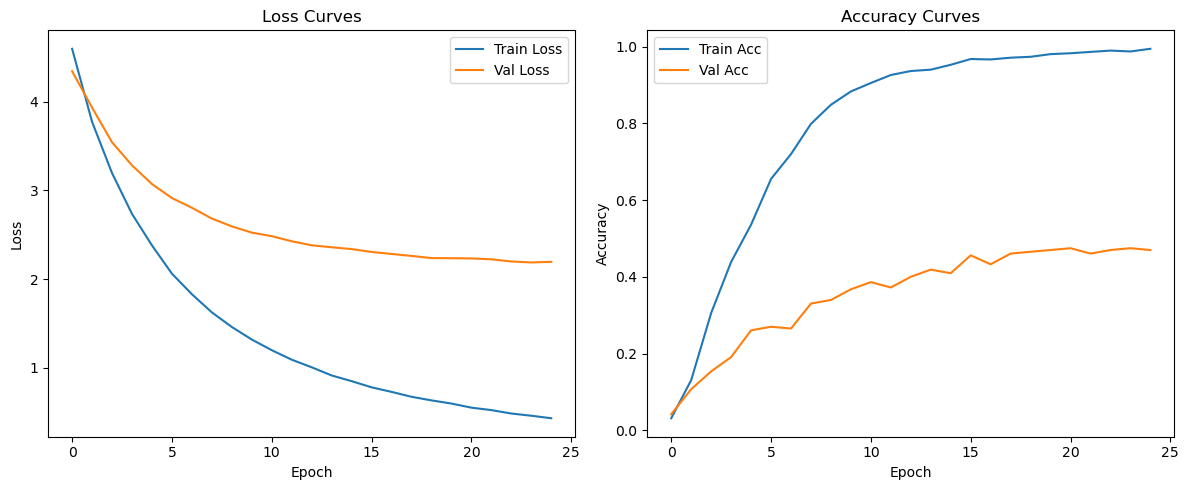

In [32]:
# Q3.4: Plot curves
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Create two plots: one for loss (train vs val), one for accuracy (train vs val)
# - Use the history dictionary to get the values
# - Add labels, legends, and display the plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()
# ========== YOUR CODE ENDS HERE ============

## 4. Testing (5 pts)

In [38]:
checkpoint = torch.load(ckpt_path, map_location="cpu")
model_temp.load_state_dict(checkpoint["model_state_dict"])
id_list = []
pred = []
model_temp.eval()

with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(device)
        outputs = model_temp(images)
        temp, predicted = torch.max(outputs, 1)
        id_list.extend(ids)
        pred.extend(predicted.cpu().tolist())

panda_dict = {"ID" : id_list, "Label" : pred}
df = pd.DataFrame(panda_dict)


df.to_csv('submission.csv', index=False)